In [13]:
import pandas as pd

df = pd.read_csv(
    '/Users/lgu/Desktop/ISWC2026-test/final/results_xml/time.tsv',
    sep='\t',
    header=None,
    names=["input_size", "format", "query_type", "TPs", "VARs", "VARs_ON_P", "SOL_P", "NODES", "BINDINGS", "EXECUTOR", "TIME"]
)

df = df[~df["TIME"].isin(["-"])].copy()

print(f"Number of runs {len((df))}")
print(f"Number of timeouts {len((df[df["TIME"] == "T"]))}")

# Print the rows where TIME is "T"
print(df[df["TIME"] == "T"])

df = df[~df["TIME"].isin(["T"])].copy()
df["TIME"] = pd.to_numeric(df["TIME"])

Number of runs 1017
Number of timeouts 0
Empty DataFrame
Columns: [input_size, format, query_type, TPs, VARs, VARs_ON_P, SOL_P, NODES, BINDINGS, EXECUTOR, TIME]
Index: []


In [14]:
import os

directory = "/Users/lgu/Desktop/ISWC2026-test/final/results_xml/"
count = 0

for filename in os.listdir(directory):
    if filename.endswith(".tsv"):
        filepath = os.path.join(directory, filename)
        with open(filepath, 'r') as file:
            if "OutOfMemory" in file.read():
                count += 1

print(f"Number of .tsv files containing 'OutOfMemory': {count}")

Number of .tsv files containing 'OutOfMemory': 3


In [23]:
len(df[df["BINDINGS"] == 0]) 

309

In [16]:
len(df[df["BINDINGS"] == 0]) / len(df)  

0.30383480825958703

In [ ]:
df[df["BINDINGS"] == 0]

In [17]:
df[["H", "K"]] = df["query_type"].str.extract(r"H=(\d+)_K=(\d+)").astype(int)

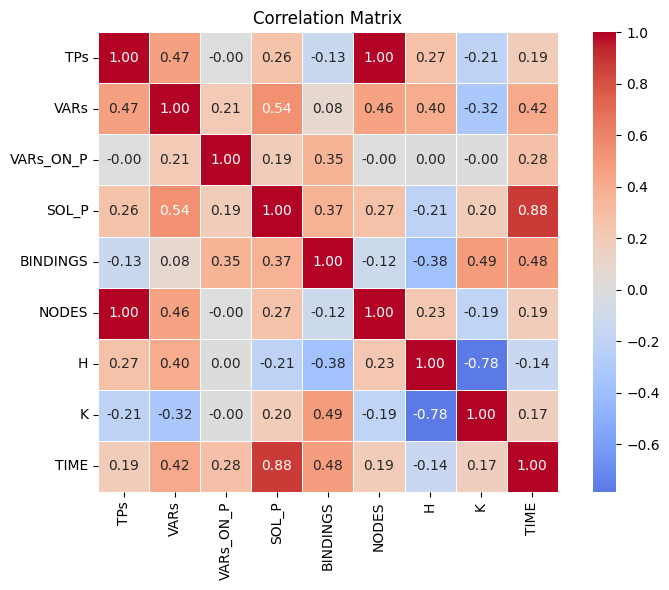

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ["TPs", "VARs", "VARs_ON_P", "SOL_P", "BINDINGS", "NODES", "H", "K", "TIME"]
corr = df[cols].apply(pd.to_numeric, errors="coerce").corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()


In [19]:
corr = df[["TPs", "VARs", "VARs_ON_P", "SOL_P", "BINDINGS", "TIME", "NODES", "H", "K"]].corr()
print(corr.to_string(float_format="{:.2f}".format))

            TPs  VARs  VARs_ON_P  SOL_P  BINDINGS  TIME  NODES     H     K
TPs        1.00  0.47      -0.00   0.26     -0.13  0.19   1.00  0.27 -0.21
VARs       0.47  1.00       0.21   0.54      0.08  0.42   0.46  0.40 -0.32
VARs_ON_P -0.00  0.21       1.00   0.19      0.35  0.28  -0.00  0.00 -0.00
SOL_P      0.26  0.54       0.19   1.00      0.37  0.88   0.27 -0.21  0.20
BINDINGS  -0.13  0.08       0.35   0.37      1.00  0.48  -0.12 -0.38  0.49
TIME       0.19  0.42       0.28   0.88      0.48  1.00   0.19 -0.14  0.17
NODES      1.00  0.46      -0.00   0.27     -0.12  0.19   1.00  0.23 -0.19
H          0.27  0.40       0.00  -0.21     -0.38 -0.14   0.23  1.00 -0.78
K         -0.21 -0.32      -0.00   0.20      0.49  0.17  -0.19 -0.78  1.00


In [20]:
df = df[df["BINDINGS"] == 0].copy()

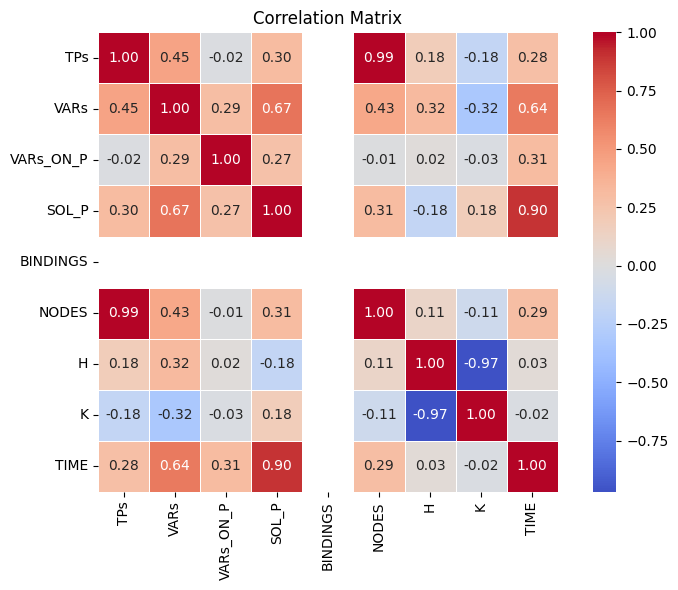

In [21]:
cols = ["TPs", "VARs", "VARs_ON_P", "SOL_P", "BINDINGS", "NODES", "H", "K", "TIME"]
corr = df[cols].apply(pd.to_numeric, errors="coerce").corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()


In [11]:
import pandas as pd

mem_files = [os.path.join(directory, f) for f in os.listdir(directory) if f.startswith('MEM_') and f.endswith('.tsv')]

dfs = []
for file in mem_files:
    df_mem = pd.read_csv(file, sep='\t')
    dfs.append(df_mem)

all_mem = pd.concat(dfs, ignore_index=True)

# Clean %cpu column if it has '%' symbol
if '%cpu' in all_mem.columns:
    all_mem['%cpu'] = all_mem['%cpu'].astype(str).str.rstrip('%').astype(float)
    # Convert vsz from bytes to megabytes
    all_mem['vsz'] = all_mem['vsz'] / (1024 * 1024)
# Analyze %cpu and vsz
print("Descriptive statistics for %cpu:")
print(all_mem['%cpu'].describe())
print("\nDescriptive statistics for vsz:")
print(all_mem['vsz'].describe())

Descriptive statistics for %cpu:
count    40393.000000
mean       111.242285
std         68.171672
min          0.000000
25%        100.100000
50%        103.300000
75%        110.000000
max        382.100000
Name: %cpu, dtype: float64

Descriptive statistics for vsz:
count    40393.000000
mean        34.943522
std          1.567679
min          0.000000
25%         35.215580
50%         35.227364
75%         35.240784
max         35.280052
Name: vsz, dtype: float64


In [22]:
import os
err_files = [f for f in os.listdir(directory) if f.startswith("ERR_")]
non_empty_err_files = []
oom_err_files = []

for filename in err_files:
    filepath = os.path.join(directory, filename)
    with open(filepath, 'r', errors='ignore') as f:
        text = f.read()
    if text.strip():
        non_empty_err_files.append(filename)
        if "OutOfMemory" in text:
            oom_err_files.append(filename)

print("File ERR_ con contenuto testo:")
for f in non_empty_err_files:
    print(f)

print("\nFile ERR_ contenenti 'OutOfMemory':")
for f in oom_err_files:
    print(f)

File ERR_ con contenuto testo:
ERR_H=2_K=1000T_10_12_1_100000_xml_stream2.tsv
ERR_H=2_K=1000T_10_12_1_100000_xml_stream3.tsv
ERR_H=2_K=1000T_10_12_1_100000_xml_stream1.tsv

File ERR_ contenenti 'OutOfMemory':
ERR_H=2_K=1000T_10_12_1_100000_xml_stream2.tsv
ERR_H=2_K=1000T_10_12_1_100000_xml_stream3.tsv
ERR_H=2_K=1000T_10_12_1_100000_xml_stream1.tsv


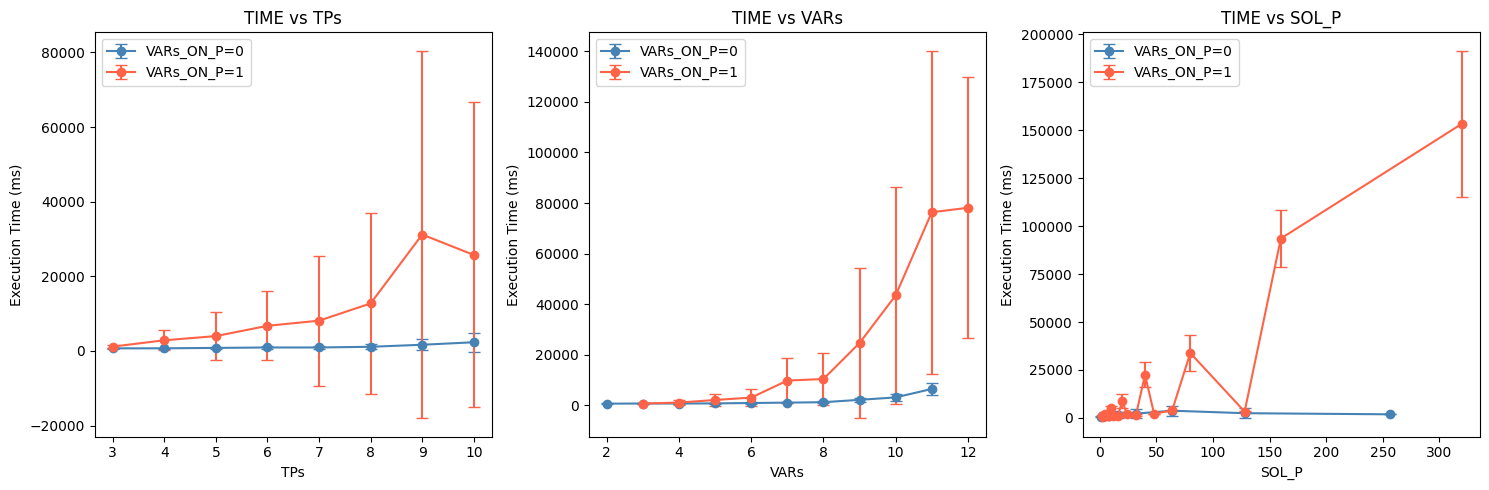

In [27]:
import matplotlib.pyplot as plt

factors = ["TPs", "VARs", "SOL_P"]
colors = {0: "steelblue", 1: "tomato"}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, factor in zip(axes, factors):
    for var_on_p, group in df.groupby("VARs_ON_P"):
        stats = group.groupby(factor)["TIME"].agg(["mean", "std"]).reset_index()
        ax.errorbar(stats[factor], stats["mean"], yerr=stats["std"],
                    marker="o", capsize=4, color=colors[var_on_p],
                    label=f"VARs_ON_P={var_on_p}")
    ax.set_xlabel(factor)
    ax.set_ylabel("Execution Time (ms)")
    ax.set_title(f"TIME vs {factor}")
    ax.legend()

plt.tight_layout()
plt.show()